## EDA – Analyse exploratoire du dataset "Entreprises entites stagiaires.csv"
### 1. Introduction, Contexte et Objectifs
#### 1.1 Origine du fichier
Le fichier analysé Entreprises entites stagiaires.csv est un export brut extrait directement du progiciel de gestion académique Aurion. Ce fichier centralise tout l'historique des relations de l'établissement avec le monde professionnel : l'identification des structures, les interlocuteurs clés (Direction, RH), les flux pédagogiques (suivi des stagiaires, apprentis et alternants), ainsi que les flux financiers liés à la collecte de la Taxe d'Apprentissage.

#### 1.2 Objectif du notebook
Ce notebook a pour objectif de mener une Analyse Exploratoire des Données (EDA) approfondie sur cet export brut. Il s'agit de cartographier le jeu de données, de mesurer sa complétude, de comprendre sa granularité réelle et de détecter toutes les anomalies de typage ou de structure avant d'envisager la moindre automatisation.

#### 1.3 Lien avec le POC2
Dans le cadre du POC2, notre objectif final est d'intégrer ces données de manière propre et structurée dans notre base de données MongoDB, puis de les mapper vers le CRM (CremeCRM). Ce notebook sert de fondation critique pour le POC2 : il permet de valider si le fichier est techniquement et fonctionnellement exploitable, et de définir le schéma documentaire (NoSQL) le plus adapté pour répondre aux besoins métiers du CRM.

#### 1.4 But de l’EDA avant l’ETL (Réflexion Métier)
Règle d'or : On ne code pas un script d'import sans comprendre la donnée. Le but de cette EDA avant l'écriture du pipeline ETL est d'éviter un import naïf "ligne par ligne" qui casserait la base de données. L'EDA doit nous dicter les règles de nettoyage et de restructuration à appliquer dans l'ETL (par exemple, comment gérer les cases vides, comment isoler les entités pour éviter les doublons, ou comment transformer les formats d'écriture complexes). Elle apporte une forte valeur ajoutée à ton rapport d'alternance en montrant la transition logique entre une source brute et un modèle métier qualifié.

### 2. Description du Fichier Source et Métadonnées
#### 2.1 Présence du préambule Aurion
L'analyse visuelle et textuelle du fichier brut montre qu'il commence par 21 lignes de préambule parasite. Ce ne sont pas des données exploitables, mais les critères et filtres d'extraction configurés dans Aurion lors de la génération du fichier.
Exemples de filtres présents dans le préambule :

Et Code pas comme SUPP_%

Et Code différent de ENSEIGNEMENT

Et Code égal à STAGE

Et Début supérieur ou égal à 01/01/2016

Décision technique validée : Le script de lecture sous Pandas devra obligatoirement utiliser l'argument skiprows=21 avec un encodage latin-1 pour ignorer ce bloc et charger directement les en-têtes de colonnes métiers.

#### 2.2 Volumétrie et Structure Globale (Après Préambule)
Volume : 13 345 lignes (enregistrements relationnels).

Dimension : 24 colonnes (variables).

Répartition thématique des variables :
Identité Entité : Code.Entité (ID unique), Libellé.Entité (Raison sociale), Code.Type d'entité, Assujetti.Entité.

Adresse / Localisation : Rue (ligne 1 à 4).Adresse, Code postal.Ville, Nom.Ville, Code.Type d'adresse (Siège, Facturation, etc.).

Capital Humain (Contact) : Code.Fonctions, Nom.Individu, Prénom.Individu.

Activité Pédagogique & Financière : Indicateurs de volumes et listes nominatives de stagiaires/alternants, Code.Type d'événement, Montant global.Taxe versement (stocké au format écriture texte, ex: "5585,74"), Début.Événement (Date).

### 3. Points d'Attention Majeurs Découverts lors de l'Analyse
La Granularité en "Couples" (Entreprise + Contact) : Cet export n'est pas une liste d'entreprises uniques. Une même entreprise (ex: CAPELEC) est dupliquée si elle possède plusieurs contacts. De même, une entreprise (ex: DEVOTEAM) est répétée sur plusieurs lignes pour matérialiser son historique sur plusieurs années de taxe. L'ETL devra obligatoirement dénormaliser ou éclater ces lignes pour le CRM.

Le Format Écriture de la Taxe : Le montant de la taxe est stocké en chaîne de caractères avec des virgules et des espaces. Pour le POC2 et le CRM, l'EDA démontre qu'il faudra impérativement convertir ce champ en nombre décimal (float) pour permettre les calculs statistiques.

Absence Structurelle de Coordonnées : Les champs email et telephone sont absents de cet export Aurion. L'ETL devra initialiser ces structures à null pour permettre un enrichissement futur, mais ces données ne pourront pas servir immédiatement à des campagnes d'e-mailing ou de relances.

Anomalie de Doublons Purs : Le fichier contient 910 doublons parfaits (6.82% du fichier), qui devront être supprimés dès la première étape de l'ETL.

### 4. Schéma de Mapping Cible Validé par l'EDA
Pour le chargement final dans le POC2, chaque ligne du fichier plat sera éclatée en sous-documents JSON imbriqués (MongoDB) structurés ainsi :

entite : Données de l'entreprise (Unique via Code.Entité).

adresse : Bloc autonome qualifié par son type (ENTREPRISE, FACTURATION).

contact : Informations sur l'interlocuteur (Nom, Prénom, Fonction).

suivi_pedagogique_et_taxe : Historique financier (avec montant casté en décimal) et flux d'étudiants.

coordonnees : Initialisées à null pour enrichissement futur.

## 1. Importation des dépendance

In [15]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## 2. Chargement du fichier CSV et gestion du préambule
Objectif : Charger le fichier CSV en s'affranchissant des lignes de métadonnées d'extraction initiales et vérifier la structure globale (dimensions, colonnes).

In [16]:
# Configuration des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Utilisation de pathlib pour éviter la fragilité des chemins relatifs textuels
BASE_DIR = Path(".").resolve().parent
file_path = BASE_DIR / "project_data" / "raw" / "Entreprises entites stagiaires.csv"

# Lecture en sautant les 21 lignes de préambule d'Aurion
df = pd.read_csv(file_path, skiprows=21, encoding="latin-1", sep=";")

print(f"Dimensions du dataset après suppression du préambule : {df.shape}")
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

Dimensions du dataset après suppression du préambule : (13345, 24)
Nombre de lignes : 13345
Nombre de colonnes : 24


## Structure globale, Types et Qualité Initiale (Data Quality)

In [17]:
# Affichage des informations globales sur les colonnes et types
print("--- Analyse des types de colonnes ---")
df.info()

--- Analyse des types de colonnes ---
<class 'pandas.DataFrame'>
RangeIndex: 13345 entries, 0 to 13344
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Unnamed: 0                          13345 non-null  int64  
 1   Code.Entité                         13345 non-null  str    
 2   Libellé.Entité                      13335 non-null  str    
 3   Code.Type d'entité                  13245 non-null  str    
 4   Assujetti.Entité                    12104 non-null  str    
 5   Rue (ligne 1).Adresse               13262 non-null  str    
 6   Rue (ligne 2).Adresse               5764 non-null   str    
 7   Rue (ligne 3).Adresse               1221 non-null   str    
 8   Rue (ligne 4).Adresse               76 non-null     str    
 9   Code postal.Ville                   13090 non-null  str    
 10  Nom.Ville                           13090 non-null  str    
 11  Code.Type d'ad

In [18]:
# Analyse fine du taux de complétude (Valeurs manquantes)
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

df_quality = pd.DataFrame({
    'Valeurs Manquantes': missing_values,
    'Pourcentage (%)': round(missing_percentage, 2)
}).sort_values(by='Pourcentage (%)', ascending=False)

print("--- Taux de valeurs manquantes par colonne ---")
print(df_quality)

--- Taux de valeurs manquantes par colonne ---
                                    Valeurs Manquantes  Pourcentage (%)
Rue (ligne 4).Adresse                            13269            99.43
Rue (ligne 3).Adresse                            12124            90.85
Nombre de stage (sans contrat pro)               10731            80.41
Noms des stagiaires                              10731            80.41
Nombre apprentissage                             10289            77.10
Noms des apprentis                               10289            77.10
Nombre de contrat pro                             8257            61.87
Noms des alternants contrats pro                  8257            61.87
Début.Événement                                   8160            61.15
Montant global.Taxe versement                     8160            61.15
Code.Type d'événement                             8160            61.15
Rue (ligne 2).Adresse                             7581            56.81
Prénom.Individu  

### Constat Data Quality & Analyse Métier des valeurs manquantes :
* **Bloc Identité et Localisation :** Les variables cruciales comme `Code.Entité`, `Rue (ligne 1).Adresse`, `Code postal.Ville` et `Nom.Ville` ont un taux de complétude proche de 100%. L'identification basique des structures est donc hautement fiable.
* **Bloc Contacts :** Les champs liés à l'identité du contact (`Nom.Individu`, `Prénom.Individu`, `Code.Fonctions`) affichent environ **33% de valeurs manquantes**. Cela signifie qu'un tiers des lignes documente une entité sans qu'un interlocuteur physique précis n'ait été enregistré.
* **Bloc Événements (Taxe / Stages) :** Les colonnes liées aux métriques de stages, apprentissages ou événements financiers possèdent un taux de vacuité élevé (60% à 80%). **Interprétation :** Ce faible taux reflète la nature "plate" et événementielle du fichier : une ligne peut matérialiser un versement de taxe sans qu'aucun stagiaire n'y soit rattaché cette année-là.

## 3. Analyse approfondie des Axes Métier

### 3.1 Granularité : Le ratio Entreprises vs Contacts uniques
Explorons les statistiques de volumétrie et de répartition pour comprendre la structure du fichier.

In [19]:
total_lignes = len(df)
nb_entites_uniques = df['Code.Entité'].nunique()
nb_libelles_uniques = df['Libellé.Entité'].nunique()

# Statistiques exactes de la répartition des contacts
lignes_avec_contact = df[['Nom.Individu', 'Prénom.Individu']].dropna(how='all').shape[0]
lignes_sans_contact = total_lignes - lignes_avec_contact

print(f"Volume total de lignes dans l'export : {total_lignes}")
print(f"Nombre de codes entités uniques (Codes structures) : {nb_entites_uniques}")
print(f"Nombre de libellés d'entreprises uniques (Raisons sociales) : {nb_libelles_uniques}")
print(f"Lignes avec contact renseigné : {lignes_avec_contact} (soit {round((lignes_avec_contact/total_lignes)*100, 2)} %)")
print(f"Lignes sans contact renseigné : {lignes_sans_contact} (soit {round((lignes_sans_contact/total_lignes)*100, 2)} %)")

# Illustration de la duplication d'entreprise pour contacts multiples
print("\nExemple de l'entreprise 'CAPELEC' (Plusieurs contacts pour une même entité) :")
print(df[df['Libellé.Entité'] == 'CAPELEC'][['Code.Entité', 'Libellé.Entité', 'Nom.Individu', 'Prénom.Individu', 'Code.Fonctions']].head(3))

Volume total de lignes dans l'export : 13345
Nombre de codes entités uniques (Codes structures) : 6738
Nombre de libellés d'entreprises uniques (Raisons sociales) : 5921
Lignes avec contact renseigné : 8872 (soit 66.48 %)
Lignes sans contact renseigné : 4473 (soit 33.52 %)

Exemple de l'entreprise 'CAPELEC' (Plusieurs contacts pour une même entité) :
     Code.Entité Libellé.Entité Nom.Individu Prénom.Individu Code.Fonctions
1509  CAPELEC_35        CAPELEC        ABOAF         Chantal   DIRECTION_RH
1510  CAPELEC_35        CAPELEC       KREJCI         Mickael   DIRECTION_RH
1511  CAPELEC_35        CAPELEC        GOMEZ      Christelle   DIRECTION_RH


### 3.2 Analyse de la Dimension "Adresse"
La colonne `Code.Type d'adresse` qualifie la typologie de la donnée postale. Elle contient notamment : `ENTREPRISE`, `FACTURATION`, `ADRESSE2`, `ALTERNANCE_STAGE`. Ce n'est pas un détail, cela montre qu'une entreprise peut posséder plusieurs adresses selon le contexte métier (Siège vs Envoi de factures).

Répartition des types d'adresses :
Code.Type d'adresse
ENTREPRISE          10354
FACTURATION          2770
ADRESSE2              105
NaN                    73
ALTERNANCE_STAGE       43
Name: count, dtype: int64


/tmp/ipykernel_71086/2891071753.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


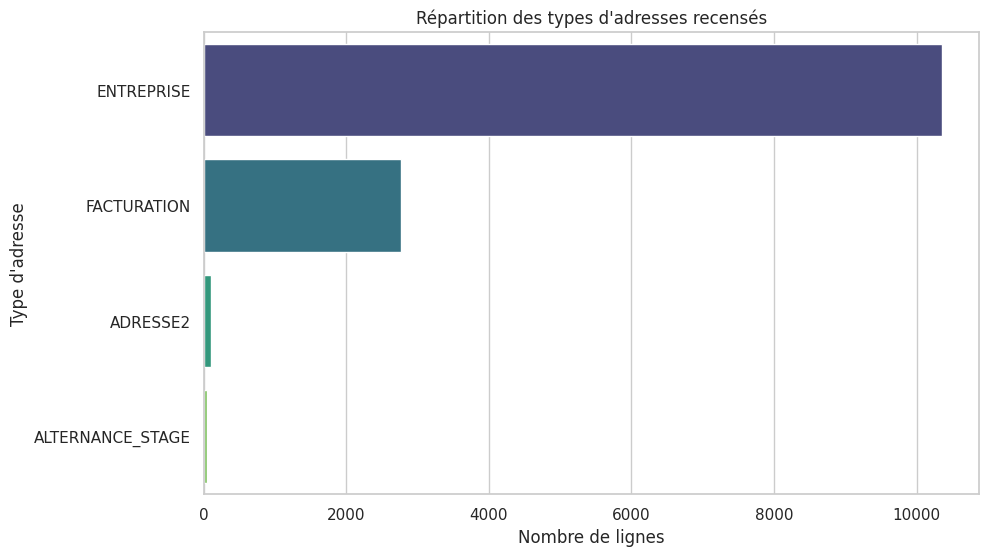

In [20]:
adresse_types = df["Code.Type d'adresse"].value_counts(dropna=False)
print("Répartition des types d'adresses :")
print(adresse_types)

sns.countplot(
    data=df, 
    y="Code.Type d'adresse", 
    order=df["Code.Type d'adresse"].value_counts().index, 
    palette="viridis"
)
plt.title("Répartition des types d'adresses recensés")
plt.xlabel("Nombre de lignes")
plt.ylabel("Type d'adresse")
plt.show()


### 3.3 Analyse de la Dimension "Événements & Historique de Taxe"

In [21]:
# Utilisation des guillemets doubles pour "Code.Type d'événement"
taxe_events = df["Code.Type d'événement"].value_counts(dropna=False)
print("Répartition des types d'événements :")
print(taxe_events)

# CORRECTION : Conversion en vraie date avec pd.to_datetime pour éliminer les résidus d'heures (ex: 08:00)
df['Date_Convertie'] = pd.to_datetime(df['Début.Événement'], format='%d/%m/%Y %H:%M', errors='coerce')
# Si le format sans heure existe aussi, on complète
df['Date_Convertie'] = df['Date_Convertie'].fillna(pd.to_datetime(df['Début.Événement'], format='%d/%m/%Y', errors='coerce'))

# Extraction propre de l'année
df['Annee_Evenement'] = df['Date_Convertie'].dt.year.astype(object).fillna('Non renseigné')

annee_distribution = df['Annee_Evenement'].value_counts()
print("\nDistribution chronologique propre des années d'événements (Taxe) :")
print(annee_distribution)


Répartition des types d'événements :
Code.Type d'événement
NaN                          8160
TAXE_VERSEMENT_ENTREPRISE    5185
Name: count, dtype: int64

Distribution chronologique propre des années d'événements (Taxe) :
Annee_Evenement
Non renseigné    8160
2025.0           1120
2022.0            791
2019.0            620
2020.0            502
2021.0            462
2017.0            393
2024.0            387
2018.0            339
2016.0            327
2026.0            244
Name: count, dtype: int64


#### Focus sur les répétitions historiques légitimes (Taxe multi-années)
Pour illustrer les doublons légitimes liés à l'historique des taxes sur plusieurs années, analysons des structures comme **IFREMER** ou **ALE INTERNATIONAL** qui présentent de réels historiques de versements.

In [22]:
# Recherche et affichage d'un exemple représentatif avec historique financier réel
df_ex_taxe = df[df['Libellé.Entité'].str.contains('IFREMER|ALE INTERNATIONAL', na=False, case=False)]
print("Exemple de duplication historique légitime (Même entreprise/contact, années différentes) :")

# CORRECTION : Utilisation de guillemets doubles pour "Code.Type d'événement"
print(df_ex_taxe[['Code.Entité', 'Libellé.Entité', "Code.Type d'événement", 'Montant global.Taxe versement', 'Début.Événement']].dropna(subset=['Montant global.Taxe versement']).head(5))


Exemple de duplication historique légitime (Même entreprise/contact, années différentes) :
                                   Code.Entité     Libellé.Entité  \
18  ALCATEL_LUCENT_ENTERPRISE_INTERNATIONAL_29  ALE INTERNATIONAL   
19  ALCATEL_LUCENT_ENTERPRISE_INTERNATIONAL_29  ALE INTERNATIONAL   
20  ALCATEL_LUCENT_ENTERPRISE_INTERNATIONAL_29  ALE INTERNATIONAL   
21  ALCATEL_LUCENT_ENTERPRISE_INTERNATIONAL_29  ALE INTERNATIONAL   
22  ALCATEL_LUCENT_ENTERPRISE_INTERNATIONAL_29  ALE INTERNATIONAL   

        Code.Type d'événement Montant global.Taxe versement   Début.Événement  
18  TAXE_VERSEMENT_ENTREPRISE                       2259,28  11/03/2025 08:00  
19  TAXE_VERSEMENT_ENTREPRISE                       2259,28  11/03/2025 08:00  
20  TAXE_VERSEMENT_ENTREPRISE                       2259,28  11/03/2025 08:00  
21  TAXE_VERSEMENT_ENTREPRISE                       2281,47  19/12/2025 08:00  
22  TAXE_VERSEMENT_ENTREPRISE                       1825,38  19/01/2024 08:00  


### 3.4 Analyse quantitative des montants de Taxe (Conversion Décimale)

In [23]:
# Traitement de la chaîne textuelle vers le format numérique pour analyse
df['Montant_Taxe_Decimal'] = df['Montant global.Taxe versement'].str.replace(',', '.', regex=False)
df['Montant_Taxe_Decimal'] = df['Montant_Taxe_Decimal'].str.replace(r'\s+', '', regex=True)
df['Montant_Taxe_Decimal'] = pd.to_numeric(df['Montant_Taxe_Decimal'], errors='coerce')

print("--- Statistiques descriptives des lignes de Taxe ---")
print(df['Montant_Taxe_Decimal'].describe())

# CORRECTION : Nuance cruciale sur le calcul de la somme globale
somme_lignes_taxe = df['Montant_Taxe_Decimal'].sum()
print(f"\n[ATTENTION] Somme cumulée brute des montants sur les lignes de l'export : {somme_lignes_taxe:,.2f} €")
print("=> Ce montant est surévalué et non fiable financièrement en l'état.")
print("=> Justification : Le fichier étant plat, un même versement est répété si l'entreprise possède plusieurs contacts ou adresses.")

--- Statistiques descriptives des lignes de Taxe ---
count     5185.000000
mean      3172.287595
std       3546.766194
min          0.010000
25%        676.000000
50%       2000.000000
75%       4785.000000
max      25621.410000
Name: Montant_Taxe_Decimal, dtype: float64

[ATTENTION] Somme cumulée brute des montants sur les lignes de l'export : 16,448,311.18 €
=> Ce montant est surévalué et non fiable financièrement en l'état.
=> Justification : Le fichier étant plat, un même versement est répété si l'entreprise possède plusieurs contacts ou adresses.


In [24]:
# Preuve de la répétition des montants (Exemple Kyndryl)
print("Démonstration du biais sur le montant total avec l'exemple 'KYNDRYL' :")
print(df[df['Libellé.Entité'].str.contains('KYNDRYL', na=False, case=False)][['Libellé.Entité', 'Montant global.Taxe versement', 'Nom.Individu']])

# Top 5 des plus grandes lignes (contenant des répétitions structurelles)
print("\nTop 5 des plus grandes lignes de versement recensées :")
print(df.nlargest(5, 'Montant_Taxe_Decimal')[['Libellé.Entité', 'Montant_Taxe_Decimal', 'Annee_Evenement']])

Démonstration du biais sur le montant total avec l'exemple 'KYNDRYL' :
           Libellé.Entité Montant global.Taxe versement Nom.Individu
9997       KYNDRYL FRANCE                       4356,42      RENAULT
9998       KYNDRYL FRANCE                       4356,42      RENAULT
9999       KYNDRYL FRANCE                      25621,41      RENAULT
10000      KYNDRYL FRANCE                       10341,6      RENAULT
10001      KYNDRYL FRANCE                       10341,6      RENAULT
10002      KYNDRYL FRANCE                       10341,6      RENAULT
10003      KYNDRYL FRANCE                       4356,42    RENNESSON
10004      KYNDRYL FRANCE                       4356,42    RENNESSON
10005      KYNDRYL FRANCE                      25621,41    RENNESSON
10006      KYNDRYL FRANCE                       10341,6    RENNESSON
10007      KYNDRYL FRANCE                       10341,6    RENNESSON
10008      KYNDRYL FRANCE                       10341,6    RENNESSON
10009      KYNDRYL FRANCE       

### 3.5 Analyse de la Dimension "Contacts & Fonctions"

Top des fonctions recensées pour les individus :
Code.Fonctions
DIRECTION_RH    4952
NaN             4412
DIRECTION       3981
Name: count, dtype: int64


/tmp/ipykernel_71086/1921025344.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_fonctions.values, y=top_fonctions.index, palette="mako")


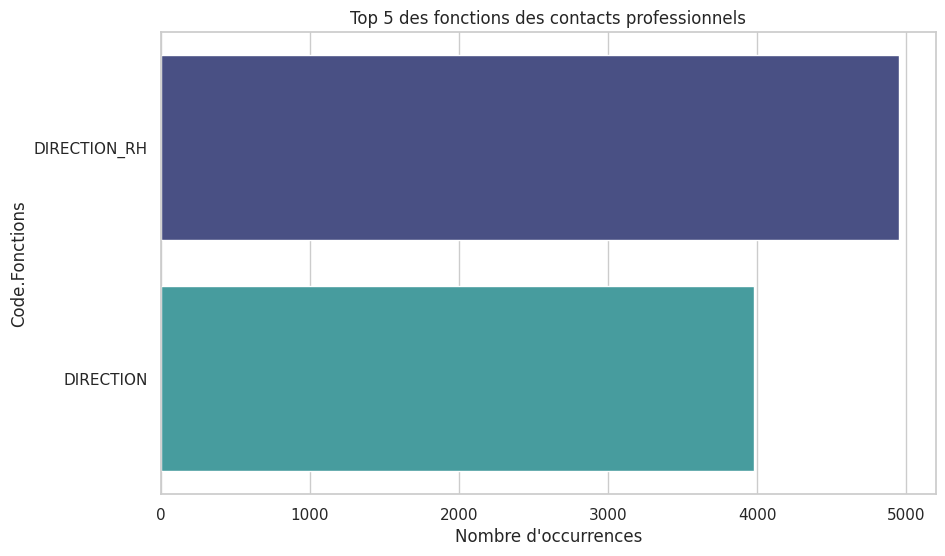

In [25]:
fonctions_contacts = df['Code.Fonctions'].value_counts(dropna=False)
print("Top des fonctions recensées pour les individus :")
print(fonctions_contacts.head(10))

top_fonctions = df['Code.Fonctions'].value_counts().head(5)
sns.barplot(x=top_fonctions.values, y=top_fonctions.index, palette="mako")
plt.title("Top 5 des fonctions des contacts professionnels")
plt.xlabel("Nombre d'occurrences")
plt.show()

## 4. Analyse des doublons pures (Contenu)

In [26]:
# Traque des doublons parfaits de contenu en excluant l'index technique Unnamed: 0
df_contenu = df.drop(columns=["Unnamed: 0"], errors="ignore")

total_lignes = len(df)
doublons_pures = df_contenu.duplicated().sum()
taux_doublons = round((doublons_pures / total_lignes) * 100, 2)

print(f"Volume total de lignes analysées : {total_lignes}")
print(f"Nombre de lignes 100% identiques (doublons de contenu pur) : {doublons_pures}")
print(f"Taux d'anomalie structurelle par duplication : {taux_doublons}%")

Volume total de lignes analysées : 13345
Nombre de lignes 100% identiques (doublons de contenu pur) : 910
Taux d'anomalie structurelle par duplication : 6.82%


## 5. Conclusion Finale de l'EDA et Synthèse Pré-ETL

À la suite de cette analyse exploratoire approfondie, voici les conclusions définitives validant le passage à l'étape d'intégration pour le POC2 :

1. **Exploitabilité globale :** Le fichier est parfaitement exploitable à condition d'ignorer les 21 lignes de préambule d'Aurion (`skiprows=21`) et d'utiliser l'encodage `latin-1`.
2. **Structure et Nature Multi-dimensions :** Ce document n'est pas une table "Entreprises", mais un export plat compilant des relations. Il mélange de force des entreprises, des adresses, des contacts et des événements (taxes/stages).
3. **Règles de gestion strictes pour l'ETL :**
   - **Suppression des doublons stricts :** Les 910 doublons parfaits de contenu doivent être supprimés de manière automatisée dès le début du script de transformation.
   - **Interdiction de suppression naïve sur le reste :** Les lignes répétées concernant une même entreprise ne doivent pas être effacées. Elles traduisent soit la présence de contacts multiples (ex: *CAPELEC*), soit un historique de versement sur plusieurs années (ex: *IFREMER*). Elles doivent être regroupées et restructurées, pas supprimées.
   - **Obligation de découpage (Mapping CRM) :** Pour éviter d'altérer la qualité des données dans CremeCRM, il faudra obligatoirement éclater chaque ligne en entités indépendantes et reliées :
     - **Entreprise (Organisation) :** Créée une seule fois à partir du `Code.Entité` unique.
     - **Contact :** Créé séparément pour isoler les interlocuteurs, puis lié à la bonne organisation.
     - **Adresse :** Stockée dans un bloc autonome pour gérer les adresses multiples (Facturation vs Siège).
     - **Historique Taxe :** Stocké de manière chronologique dans un modèle dédié.
   - **Conversion des formats :** L'ETL devra obligatoirement convertir le format d'écriture textuel des taxes en vrais nombres décimaux (`float`) pour le NoSQL/CRM, et nettoyer les formats de date pour permettre un requêtage temporel fiable.
   - **Gestion des coordonnées :** Les champs `email` et `telephone` étant absents, la structure cible sera initialisée à `null` dans l'attente d'une phase d'enrichissement de données.